<a href="https://colab.research.google.com/github/synexiaofficial-byte/crowd-navi/blob/main/lecture6_2_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

ランダムに協力・裏切りするプレイヤー

In [ ]:
T = 50

actions = ["C", "D"]  # C: 協力, D: 裏切り

player_A = []
player_B = []

for t in range(T):
    a = np.random.choice(actions)
    b = np.random.choice(actions)
    player_A.append(a)
    player_B.append(b)

print("A:", player_A[:20])
print("B:", player_B[:20])

A: [np.str_('D'), np.str_('D'), np.str_('C'), np.str_('D'), np.str_('C'), np.str_('D'), np.str_('D'), np.str_('D'), np.str_('C'), np.str_('D'), np.str_('C'), np.str_('D'), np.str_('D'), np.str_('D'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('D'), np.str_('D'), np.str_('D')]
B: [np.str_('C'), np.str_('C'), np.str_('D'), np.str_('D'), np.str_('D'), np.str_('C'), np.str_('C'), np.str_('D'), np.str_('C'), np.str_('D'), np.str_('D'), np.str_('D'), np.str_('D'), np.str_('C'), np.str_('D'), np.str_('D'), np.str_('C'), np.str_('D'), np.str_('D'), np.str_('C')]


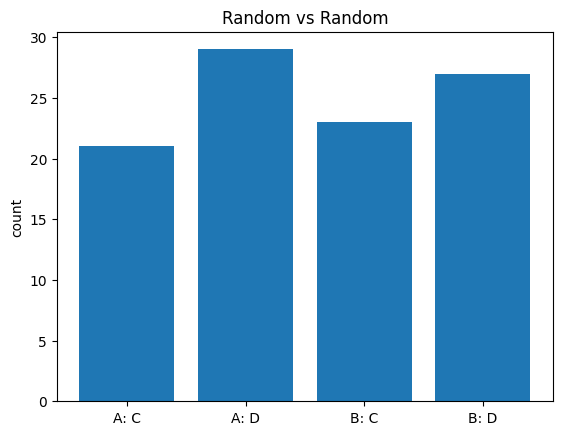

In [ ]:
def count_actions(action_list):
    return action_list.count("C"), action_list.count("D")

cA, dA = count_actions(player_A)
cB, dB = count_actions(player_B)

plt.bar(["A: C", "A: D", "B: C", "B: D"], [cA, dA, cB, dB])
plt.ylabel("count")
plt.title("Random vs Random")
plt.show()

囚人のジレンマの利得を計算する。

In [ ]:
def payoff(a, b):
    """
    a, b は "C" または "D"
    戻り値は (Aの得点, Bの得点)
    """
    if a == "C" and b == "C":
        return 3, 3
    elif a == "C" and b == "D":
        return 0, 5
    elif a == "D" and b == "C":
        return 5, 0
    else:
        return 1, 1

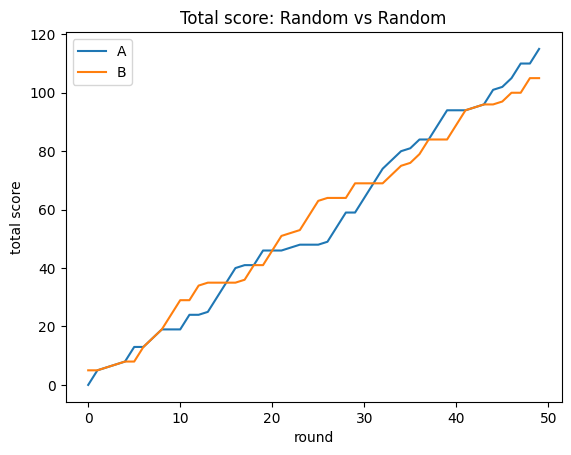

A total: 115
B total: 105


In [ ]:
score_A = 0
score_B = 0

scores_A = []
scores_B = []

for a, b in zip(player_A, player_B):
    sA, sB = payoff(a, b)
    score_A += sA
    score_B += sB
    scores_A.append(score_A)
    scores_B.append(score_B)

plt.plot(scores_A, label="A")
plt.plot(scores_B, label="B")
plt.xlabel("round")
plt.ylabel("total score")
plt.title("Total score: Random vs Random")
plt.legend()
plt.show()

print("A total:", score_A)
print("B total:", score_B)

Tit for Tat しっぺ返し戦略

In [ ]:
T = 50

player_A = []
player_B = []

for t in range(T):
    # A: Tit for Tat
    if t == 0:
        a = "C"
    else:
        a = player_B[t-1]

    # B: Random
    b = np.random.choice(actions)

    player_A.append(a)
    player_B.append(b)

print("A:", player_A[:20])
print("B:", player_B[:20])

A: ['C', np.str_('D'), np.str_('C'), np.str_('D'), np.str_('C'), np.str_('C'), np.str_('D'), np.str_('D'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('D'), np.str_('D'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('D'), np.str_('C')]
B: [np.str_('D'), np.str_('C'), np.str_('D'), np.str_('C'), np.str_('C'), np.str_('D'), np.str_('D'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('D'), np.str_('D'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('D'), np.str_('C'), np.str_('D')]


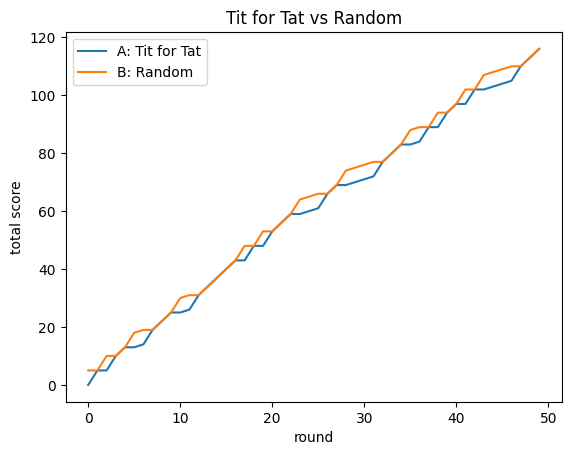

A total: 116
B total: 116


In [ ]:
score_A = 0
score_B = 0
scores_A = []
scores_B = []

for a, b in zip(player_A, player_B):
    sA, sB = payoff(a, b)
    score_A += sA
    score_B += sB
    scores_A.append(score_A)
    scores_B.append(score_B)

plt.plot(scores_A, label="A: Tit for Tat")
plt.plot(scores_B, label="B: Random")
plt.xlabel("round")
plt.ylabel("total score")
plt.title("Tit for Tat vs Random")
plt.legend()
plt.show()

print("A total:", score_A)
print("B total:", score_B)

Grim Trigger 一度裏切られたら永久に裏切る

In [ ]:
T = 50

player_A = []
player_B = []

betrayed = False  # Bに一度でも裏切られたか？

for t in range(T):
    # A: Grim Trigger
    if betrayed:
        a = "D"
    else:
        a = "C"

    # B: Random
    b = np.random.choice(actions)

    # Bが裏切ったら記録する
    if b == "D":
        betrayed = True

    player_A.append(a)
    player_B.append(b)

print("A:", player_A[:20])
print("B:", player_B[:20])

A: ['C', 'C', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D']
B: [np.str_('C'), np.str_('D'), np.str_('D'), np.str_('D'), np.str_('C'), np.str_('C'), np.str_('D'), np.str_('D'), np.str_('D'), np.str_('D'), np.str_('C'), np.str_('D'), np.str_('C'), np.str_('D'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('D'), np.str_('D')]


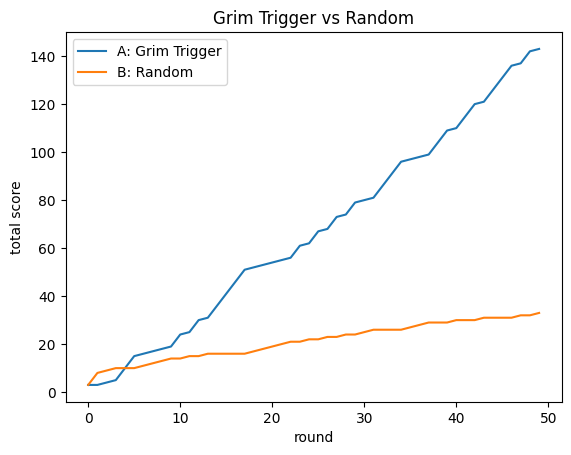

A total: 143
B total: 33


In [ ]:
score_A = 0
score_B = 0
scores_A = []
scores_B = []

for a, b in zip(player_A, player_B):
    sA, sB = payoff(a, b)
    score_A += sA
    score_B += sB
    scores_A.append(score_A)
    scores_B.append(score_B)

plt.plot(scores_A, label="A: Grim Trigger")
plt.plot(scores_B, label="B: Random")
plt.xlabel("round")
plt.ylabel("total score")
plt.title("Grim Trigger vs Random")
plt.legend()
plt.show()

print("A total:", score_A)
print("B total:", score_B)

状態を表示してみる

In [ ]:
T = 20

player_A = []
player_B = []

betrayed = False

print("round | state(betrayed) | A | B")
print("-------------------------------")

for t in range(T):
    if betrayed:
        a = "D"
    else:
        a = "C"

    b = np.random.choice(actions)

    print(f"{t:5d} | {str(betrayed):14s} | {a} | {b}")

    if b == "D":
        betrayed = True

    player_A.append(a)
    player_B.append(b)

round | state(betrayed) | A | B
-------------------------------
    0 | False          | C | C
    1 | False          | C | D
    2 | True           | D | C
    3 | True           | D | D
    4 | True           | D | D
    5 | True           | D | C
    6 | True           | D | C
    7 | True           | D | D
    8 | True           | D | C
    9 | True           | D | D
   10 | True           | D | C
   11 | True           | D | D
   12 | True           | D | C
   13 | True           | D | C
   14 | True           | D | C
   15 | True           | D | C
   16 | True           | D | D
   17 | True           | D | D
   18 | True           | D | C
   19 | True           | D | D
